# 01 — Dataset Preparation, Visualization, and Manuscript-Grade Drift Protocol

This notebook prepares and analyzes the two domains used by the study:

**Cross-Domain Validation of Deep Learning-Based Systematic Measurement Drift Detection Using Industrial Sensor Data**

It produces three distinct evidence layers:

1. a sparse mixed-fault benchmark with approximately realistic anomaly prevalence;
2. a balanced severity–duration scenario protocol shared across Gas Sensor and SKAB;
3. observational natural/native data for separate evaluation.

All tables used by figures are stored as CSV files.


In [1]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

from drift_detection.config import load_config

config = load_config()
print(f"Project root: {PROJECT_ROOT}")
print(f"Experiment version: {config['project']['experiment_version']}")
print(f"Scenario profile: {config['experiment']['profile']}")

from drift_detection.benchmark import prepare_all_benchmarks
from drift_detection.eda import run_dataset_eda


Project root: /home/commu10/Documents/BT/cross_domain_drift_detection_manuscript_v2/cross_domain_drift_detection
Experiment version: manuscript_v2
Scenario profile: manuscript


## Experiment controls

Use `manuscript` for the final experiment. The `quick` profile is intended only for code validation and produces fewer scenarios.


In [2]:
EXPERIMENT_PROFILE = "manuscript"  # "quick" or "manuscript"
PREPARATION_SEED = 42
DOWNLOAD_DATASETS = True

config["experiment"]["profile"] = EXPERIMENT_PROFILE
print("Configured random seeds:", config["project"]["seed_list"])


Configured random seeds: [42, 52, 62, 72, 82]


## Reproducibility environment audit

The package, Python, operating-system, and accelerator versions are saved before data preparation.

In [3]:
import importlib.metadata
import platform
import shutil

packages = ["numpy", "pandas", "scipy", "scikit-learn", "torch", "matplotlib", "deepod"]
rows = []
for package in packages:
    try:
        version = importlib.metadata.version(package)
    except importlib.metadata.PackageNotFoundError:
        version = "not_installed"
    rows.append({"component": package, "version": version})
rows.extend([
    {"component": "python", "version": platform.python_version()},
    {"component": "platform", "version": platform.platform()},
    {"component": "cuda_available", "version": str(__import__("torch").cuda.is_available())},
    {"component": "cuda_device", "version": __import__("torch").cuda.get_device_name(0) if __import__("torch").cuda.is_available() else "cpu"},
])
environment = pd.DataFrame(rows)
environment_path = config["paths"]["results"] / "data" / "environment_versions.csv"
environment_path.parent.mkdir(parents=True, exist_ok=True)
environment.to_csv(environment_path, index=False)
shutil.copy2(PROJECT_ROOT / "configs" / "default.yaml", config["paths"]["results"] / "data" / "config_snapshot.yaml")
display(environment)


/home/commu10/.local/lib/python3.12/site-packages/torch/cuda/__init__.py:1061: UserWarning: Can't initialize NVML
  raw_cnt = _raw_device_count_nvml()


,component,version
0,numpy,2.4.4
1,pandas,3.0.3
2,scipy,1.18.0
3,scikit-learn,1.9.0
4,torch,2.11.0+cu128
5,matplotlib,3.11.1
6,deepod,not_installed
7,python,3.12.3
8,platform,Linux-7.0.0-28-generic-x86_64-with-glibc2.39
9,cuda_available,True


## Download or locate the datasets

Set `DOWNLOAD_DATASETS = True` only when the raw files are not already present.


In [4]:
if DOWNLOAD_DATASETS:
    import subprocess
    subprocess.run(
        [sys.executable, str(PROJECT_ROOT / "scripts" / "download_datasets.py"), "--all"],
        check=True,
        cwd=PROJECT_ROOT,
    )


gas_sensor_drift.zip: 10.1MB [00:26, 378kB/s] 


Gas Sensor dataset extracted to /home/commu10/Documents/BT/cross_domain_drift_detection_manuscript_v2/cross_domain_drift_detection/data/raw/gas_sensor


skab_master.zip: 5.10MB [00:04, 1.23MB/s]

SKAB dataset extracted to /home/commu10/Documents/BT/cross_domain_drift_detection_manuscript_v2/cross_domain_drift_detection/data/raw/skab


skab_master.zip: 5.41MB [00:04, 1.14MB/s]


## Raw-data inventory

This audit prevents incomplete downloads from silently entering the study.


In [5]:
gas_files = sorted(config["paths"]["raw_gas"].rglob("batch*.dat"))
skab_files = sorted(config["paths"]["raw_skab"].rglob("*.csv"))

inventory = pd.DataFrame([
    {
        "dataset": "gas_sensor",
        "file_count": len(gas_files),
        "total_bytes": sum(path.stat().st_size for path in gas_files),
        "root": str(config["paths"]["raw_gas"]),
    },
    {
        "dataset": "skab",
        "file_count": len(skab_files),
        "total_bytes": sum(path.stat().st_size for path in skab_files),
        "root": str(config["paths"]["raw_skab"]),
    },
])
inventory_path = config["paths"]["results"] / "data" / "raw_file_inventory.csv"
inventory_path.parent.mkdir(parents=True, exist_ok=True)
inventory.to_csv(inventory_path, index=False)
display(inventory)

if len(gas_files) < 10:
    raise FileNotFoundError("Gas Sensor batch files were not found. Enable DOWNLOAD_DATASETS.")
if len(skab_files) < 2:
    raise FileNotFoundError("SKAB CSV files were not found. Enable DOWNLOAD_DATASETS.")


,dataset,file_count,total_bytes,root
0,gas_sensor,10,23697825,/home/commu10/Documents/BT/cross_domain_drift_...
1,skab,35,4392581,/home/commu10/Documents/BT/cross_domain_drift_...


## Prepare revised benchmarks

The preparation code performs chronological splitting, context residualization for Gas Sensor, robust scaling for SKAB, sparse mixed-fault injection, and creation of exact point-by-channel fault masks.


In [6]:
preparation_outputs = prepare_all_benchmarks(config, seed=PREPARATION_SEED)
preparation_outputs


{'gas': {'benchmark': PosixPath('/home/commu10/Documents/BT/cross_domain_drift_detection_manuscript_v2/cross_domain_drift_detection/data/processed/benchmarks/gas_controlled.npz'),
  'natural': PosixPath('/home/commu10/Documents/BT/cross_domain_drift_detection_manuscript_v2/cross_domain_drift_detection/data/processed/benchmarks/gas_natural_later_batches.npz'),
  'scenario_manifest': PosixPath('/home/commu10/Documents/BT/cross_domain_drift_detection_manuscript_v2/cross_domain_drift_detection/data/processed/benchmarks/gas_sensor_scenario_manifest.csv'),
  'residualizer': PosixPath('/home/commu10/Documents/BT/cross_domain_drift_detection_manuscript_v2/cross_domain_drift_detection/data/processed/gas_context_residualizer.joblib'),
  'event_manifest': PosixPath('/home/commu10/Documents/BT/cross_domain_drift_detection_manuscript_v2/cross_domain_drift_detection/results/data/gas_fault_injection_manifest.csv'),
  'summary': PosixPath('/home/commu10/Documents/BT/cross_domain_drift_detection_manusc

## Verify sparse mixed-fault prevalence and channel masks


In [7]:
benchmark_rows = []
for dataset_name, file_name in [("gas_sensor", "gas_controlled.npz"), ("skab", "skab_controlled.npz")]:
    path = config["paths"]["benchmarks"] / file_name
    with np.load(path, allow_pickle=False) as bundle:
        labels = bundle["test_labels"]
        channel_labels = bundle["test_channel_labels"]
        benchmark_rows.append({
            "dataset": dataset_name,
            "train_points": len(bundle["train_series"]),
            "validation_points": len(bundle["validation_series"]),
            "clean_test_points": len(bundle["clean_test_series"]),
            "channels": bundle["clean_test_series"].shape[1],
            "mixed_test_anomaly_ratio": float(labels.mean()),
            "labeled_channel_cells": int(channel_labels.sum()),
            "benchmark_version": str(bundle["benchmark_version"][0]),
        })
benchmark_audit = pd.DataFrame(benchmark_rows)
benchmark_audit.to_csv(config["paths"]["results"] / "data" / "revised_benchmark_audit.csv", index=False)
display(benchmark_audit)


,dataset,train_points,validation_points,clean_test_points,channels,mixed_test_anomaly_ratio,labeled_channel_cells,benchmark_version
0,gas_sensor,1689,475,1272,128,0.097484,3027,manuscript_v2
1,skab,5643,1881,1881,8,0.092504,339,manuscript_v2


## Shared cross-domain scenario protocol

Scenario IDs, fault types, severities, duration levels, normalized starts, and channel fractions are identical across domains. Actual channel indices differ because Gas Sensor has 128 features and SKAB has 8 channels.


In [8]:
gas_protocol = pd.read_csv(config["paths"]["benchmarks"] / "gas_sensor_scenario_manifest.csv")
skab_protocol = pd.read_csv(config["paths"]["benchmarks"] / "skab_scenario_manifest.csv")

protocol_audit = pd.DataFrame([
    {
        "dataset": "gas_sensor",
        "scenario_count": len(gas_protocol),
        "fault_types": gas_protocol["fault_type"].nunique(),
        "severity_levels": gas_protocol["severity"].nunique(),
        "duration_levels": gas_protocol["duration_windows"].nunique(),
        "replicates": gas_protocol["replicate"].nunique(),
    },
    {
        "dataset": "skab",
        "scenario_count": len(skab_protocol),
        "fault_types": skab_protocol["fault_type"].nunique(),
        "severity_levels": skab_protocol["severity"].nunique(),
        "duration_levels": skab_protocol["duration_windows"].nunique(),
        "replicates": skab_protocol["replicate"].nunique(),
    },
])
display(protocol_audit)

shared_columns = ["scenario_id", "fault_type", "severity", "duration_windows", "replicate", "channel_fraction", "normalized_start", "scenario_seed"]
assert gas_protocol[shared_columns].equals(skab_protocol[shared_columns]), "The cross-domain scenario protocols are not identical."
display(gas_protocol[shared_columns].head(12))


,dataset,scenario_count,fault_types,severity_levels,duration_levels,replicates
0,gas_sensor,288,6,4,4,3
1,skab,288,6,4,4,3


,scenario_id,fault_type,severity,duration_windows,replicate,channel_fraction,normalized_start,scenario_seed
0,additive_s0.5_d1_r0,additive,0.5,1,0,0.10,0.193148,56731232
1,additive_s0.5_d1_r1,additive,0.5,1,1,0.25,0.423815,1374203059
2,additive_s0.5_d1_r2,additive,0.5,1,2,0.50,0.346400,1381800716
3,additive_s0.5_d2_r0,additive,0.5,2,0,0.10,0.682415,762179171
4,additive_s0.5_d2_r1,additive,0.5,2,1,0.25,0.774115,1548783627
5,additive_s0.5_d2_r2,additive,0.5,2,2,0.50,0.572228,380863079
6,additive_s0.5_d4_r0,additive,0.5,4,0,0.10,0.288642,355781145
7,additive_s0.5_d4_r1,additive,0.5,4,1,0.25,0.785880,2076535512
8,additive_s0.5_d4_r2,additive,0.5,4,2,0.50,0.558697,1297454207
9,additive_s0.5_d8_r0,additive,0.5,8,0,0.10,0.462123,1616479868


## Run visualization and exploratory drift analysis


In [9]:
eda_outputs = run_dataset_eda(config, seed=PREPARATION_SEED)
eda_outputs


{'gas': {'quality': PosixPath('/home/commu10/Documents/BT/cross_domain_drift_detection_manuscript_v2/cross_domain_drift_detection/results/data/gas_data_quality_summary.csv'),
  'batch_summary': PosixPath('/home/commu10/Documents/BT/cross_domain_drift_detection_manuscript_v2/cross_domain_drift_detection/results/data/gas_batch_summary.csv'),
  'composition': PosixPath('/home/commu10/Documents/BT/cross_domain_drift_detection_manuscript_v2/cross_domain_drift_detection/results/data/gas_batch_gas_composition.csv'),
  'concentration_summary': PosixPath('/home/commu10/Documents/BT/cross_domain_drift_detection_manuscript_v2/cross_domain_drift_detection/results/data/gas_concentration_summary.csv'),
  'natural_drift': PosixPath('/home/commu10/Documents/BT/cross_domain_drift_detection_manuscript_v2/cross_domain_drift_detection/results/data/gas_natural_drift_by_batch.csv'),
  'sensor_group_drift': PosixPath('/home/commu10/Documents/BT/cross_domain_drift_detection_manuscript_v2/cross_domain_drift_de

## Data quality and natural-shift evidence


In [10]:
for file_name in [
    "gas_data_quality_summary.csv",
    "skab_data_quality_summary.csv",
    "gas_natural_drift_by_batch.csv",
    "skab_sequence_distribution_shift.csv",
    "cross_domain_benchmark_summary.csv",
]:
    path = config["paths"]["results"] / "data" / file_name
    print(f"\n{file_name}")
    display(pd.read_csv(path).head(20))



gas_data_quality_summary.csv


,dataset,rows,channels,batches,gas_classes,missing_feature_values,duplicate_rows,minimum_concentration,median_concentration,maximum_concentration
0,gas_sensor,13910,128,10,6,0,0,1.0,100.0,1000.0



skab_data_quality_summary.csv


,dataset,rows,channels,normal_files,anomaly_files,missing_sensor_values_after_loading,duplicate_timestamps,anomaly_points,changepoints
0,skab,46806,8,1,34,0,0,13067,129



gas_natural_drift_by_batch.csv


,batch,rows,mean_absolute_residual,median_absolute_residual,root_mean_squared_residual,p95_absolute_residual,correlation_distance_from_train
0,1,445,0.491778,0.294430,0.858984,1.593372,0.200541
1,2,1244,0.372774,0.193341,3.631128,0.939905,0.111210
2,3,1586,0.673096,0.373495,1.101309,2.160314,0.376177
3,4,161,1.438358,0.732563,3.804178,3.938070,0.451835
4,5,197,0.798539,0.544135,1.285054,2.260242,0.376109
5,6,2300,0.675785,0.473944,0.949821,2.016122,0.333370
6,7,3613,0.752926,0.499382,1.103506,2.291793,0.321352
7,8,294,0.835029,0.639112,1.281663,2.214271,0.499993
8,9,470,0.683631,0.522392,2.835292,1.778659,0.436891
9,10,3600,0.909716,0.587592,1.626560,2.722070,0.314146



skab_sequence_distribution_shift.csv


,split,sequence_id,source_file,rows,anomaly_ratio,changepoint_ratio,median_absolute_level,root_mean_squared_level,correlation_distance_from_normal
0,normal,0,anomaly-free.csv,9405,0.000000,0.000000,0.221880,0.390512,0.000000
1,anomaly,0,1.csv,745,0.252349,0.002685,3.110504,7.386905,0.463237
2,anomaly,1,10.csv,1327,0.441598,0.003014,0.717636,1.158450,0.481688
3,anomaly,2,11.csv,1190,0.378992,0.003361,0.753250,1.488151,0.463125
4,anomaly,3,12.csv,1048,0.294847,0.003817,0.500000,4.534639,0.470310
5,anomaly,4,13.csv,923,0.287107,0.004334,0.500000,4.515895,0.560876
6,anomaly,5,14.csv,905,0.333702,0.003315,0.627743,1.711318,0.549279
7,anomaly,6,2.csv,780,0.492308,0.005128,2.583710,7.388421,0.419290
8,anomaly,7,3.csv,1137,0.350044,0.003518,2.747277,7.343118,0.418023
9,anomaly,8,4.csv,1191,0.331654,0.002519,2.747912,7.374333,0.329622



cross_domain_benchmark_summary.csv


,dataset,channels,train_points,validation_points,test_points,train_windows,validation_windows,test_windows,anomaly_points,anomaly_ratio,fault_families,window_size,stride
0,gas,128,1689,475,1272,415,111,311,124,0.097484,6,32,4
1,skab,8,5643,1881,1881,1403,463,463,174,0.092504,6,32,4


## Saved figures


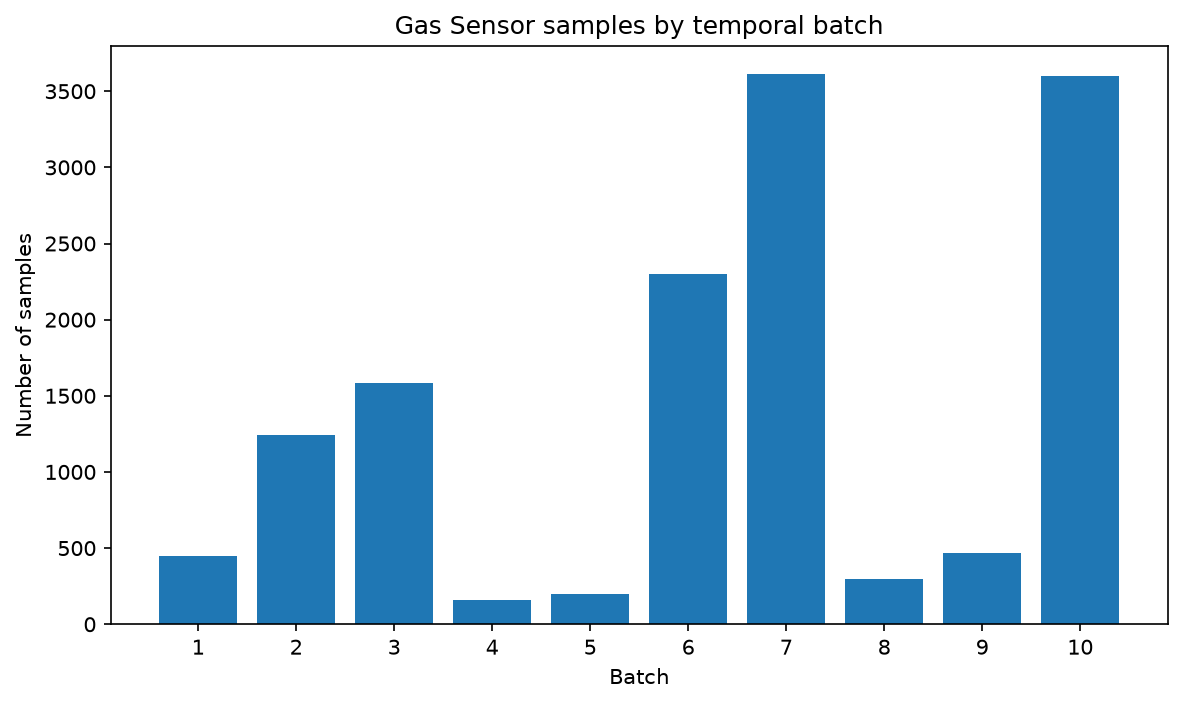

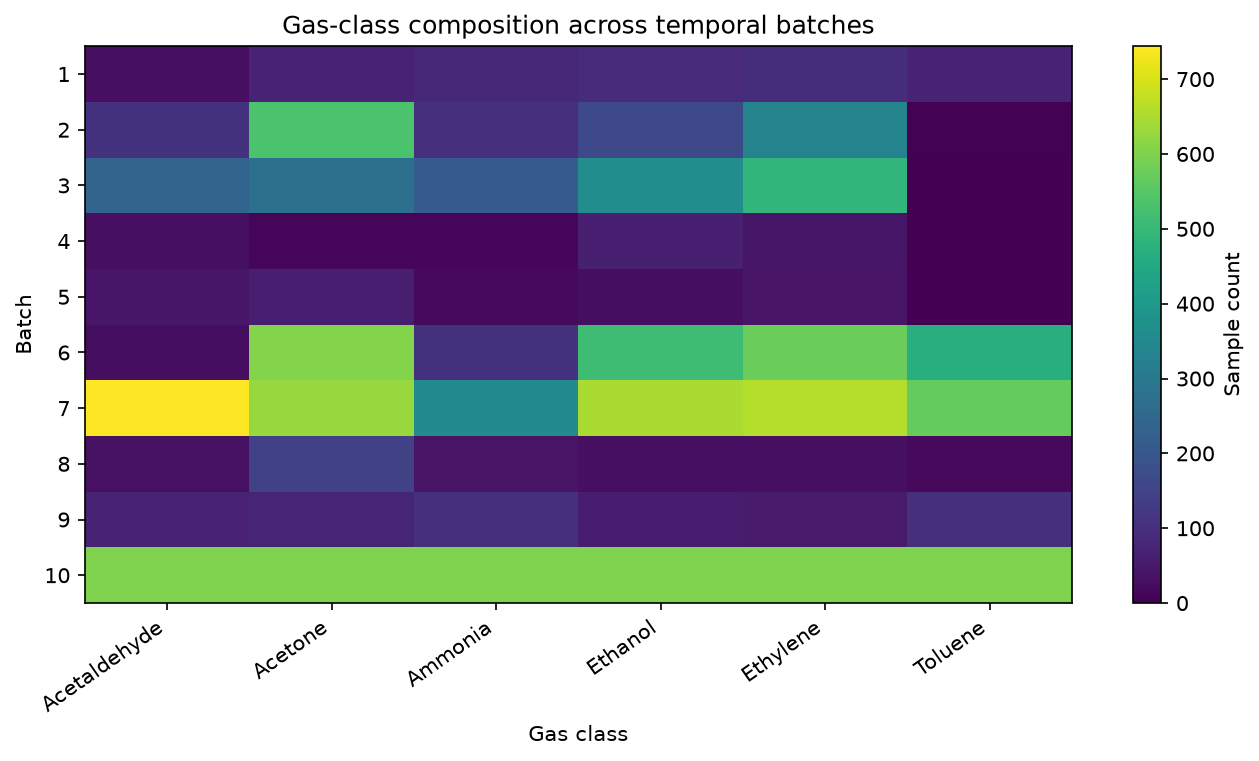

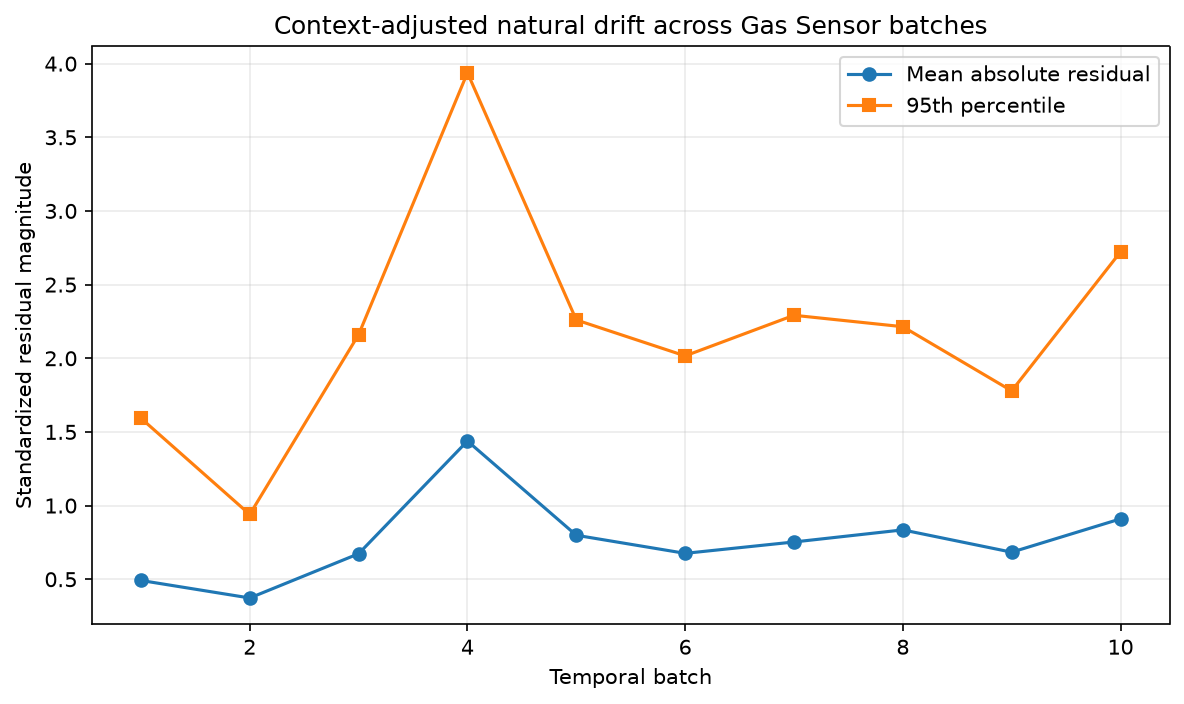

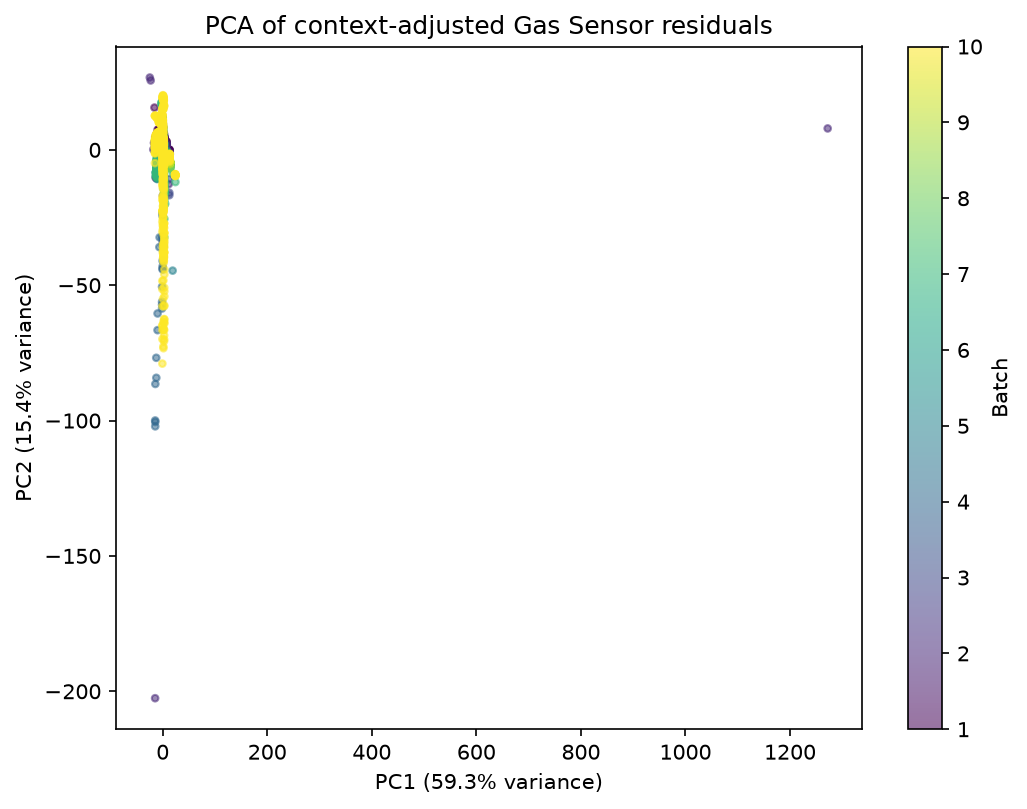

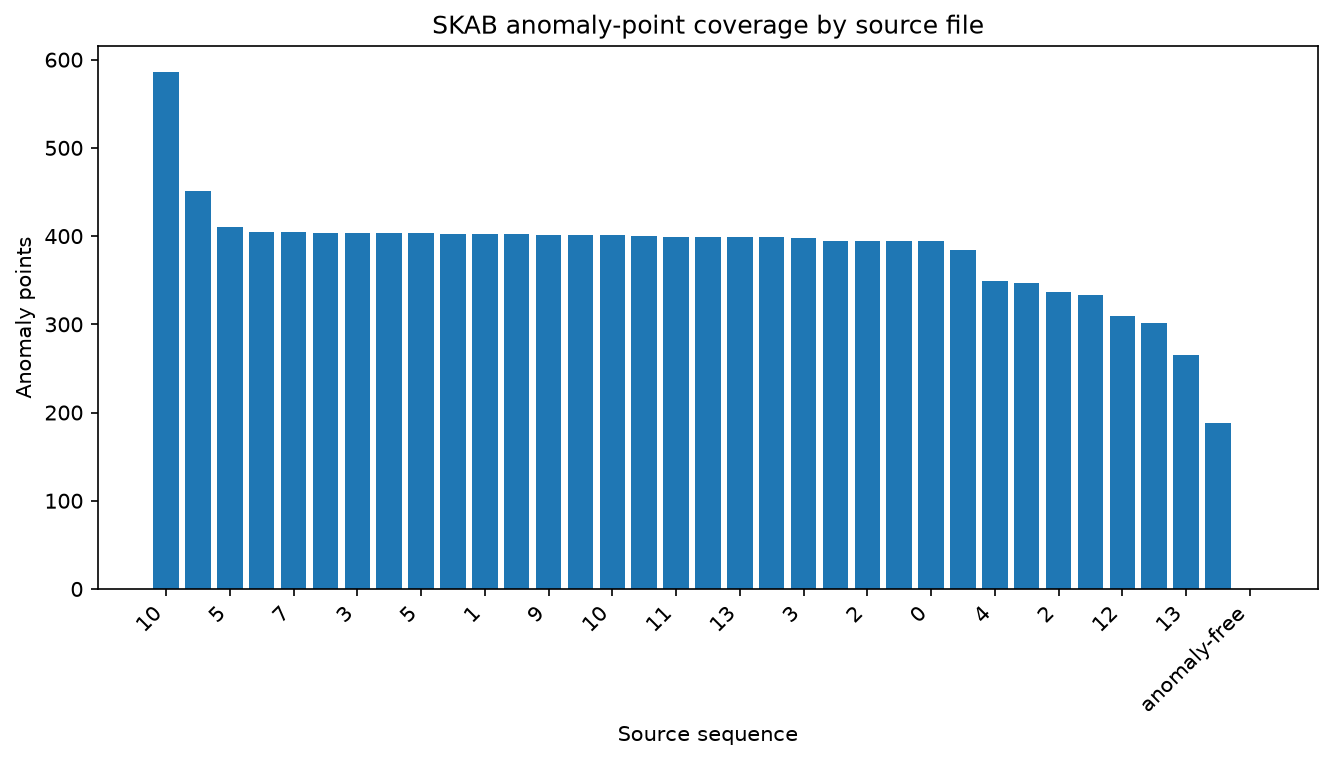

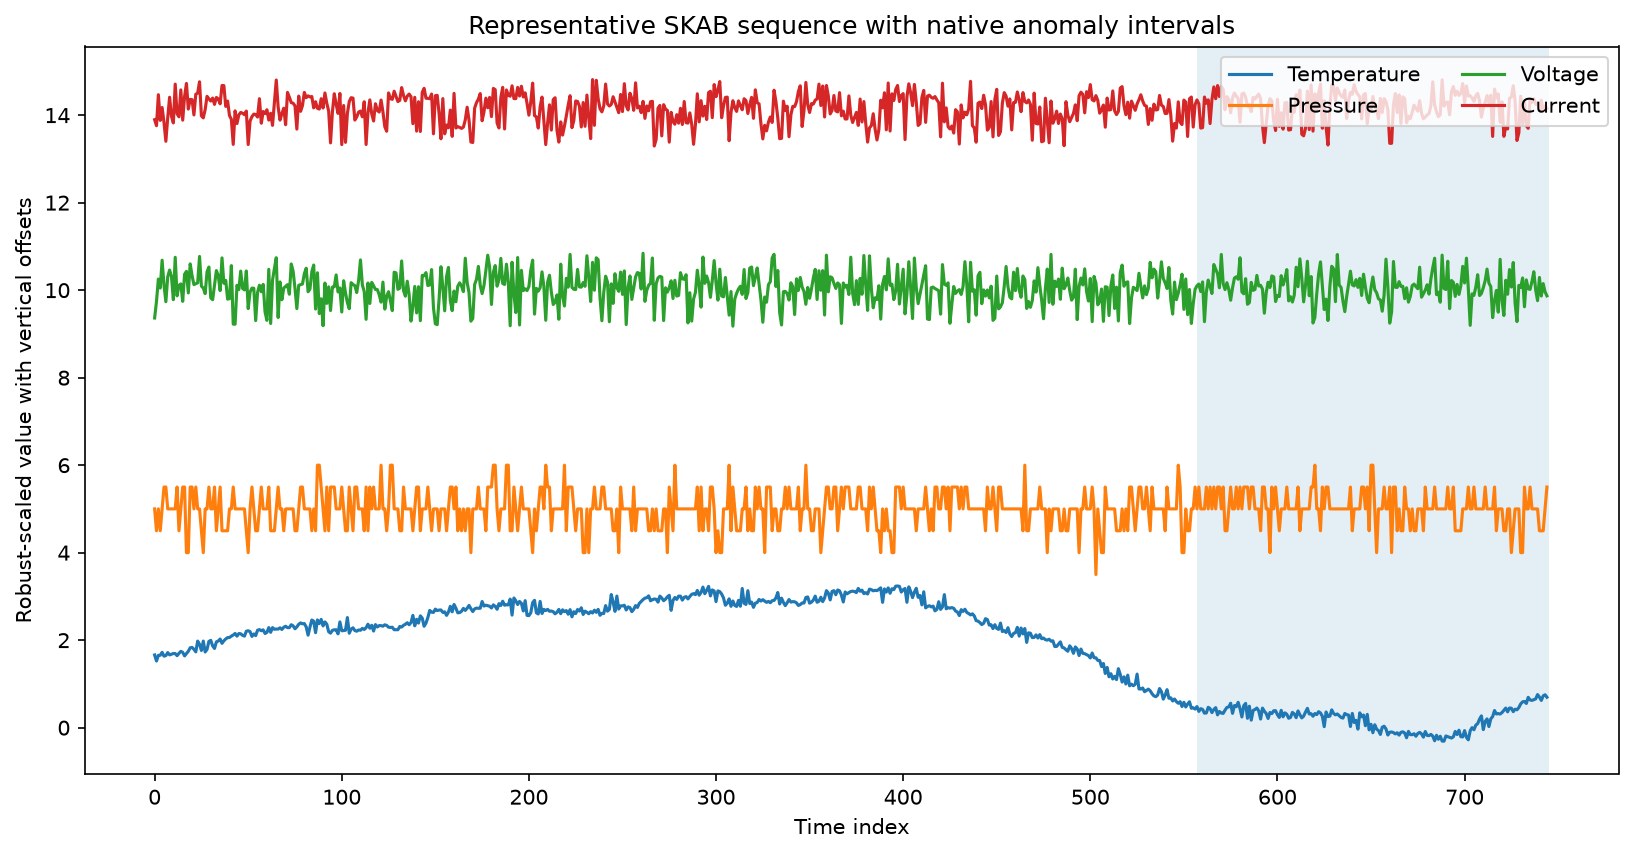

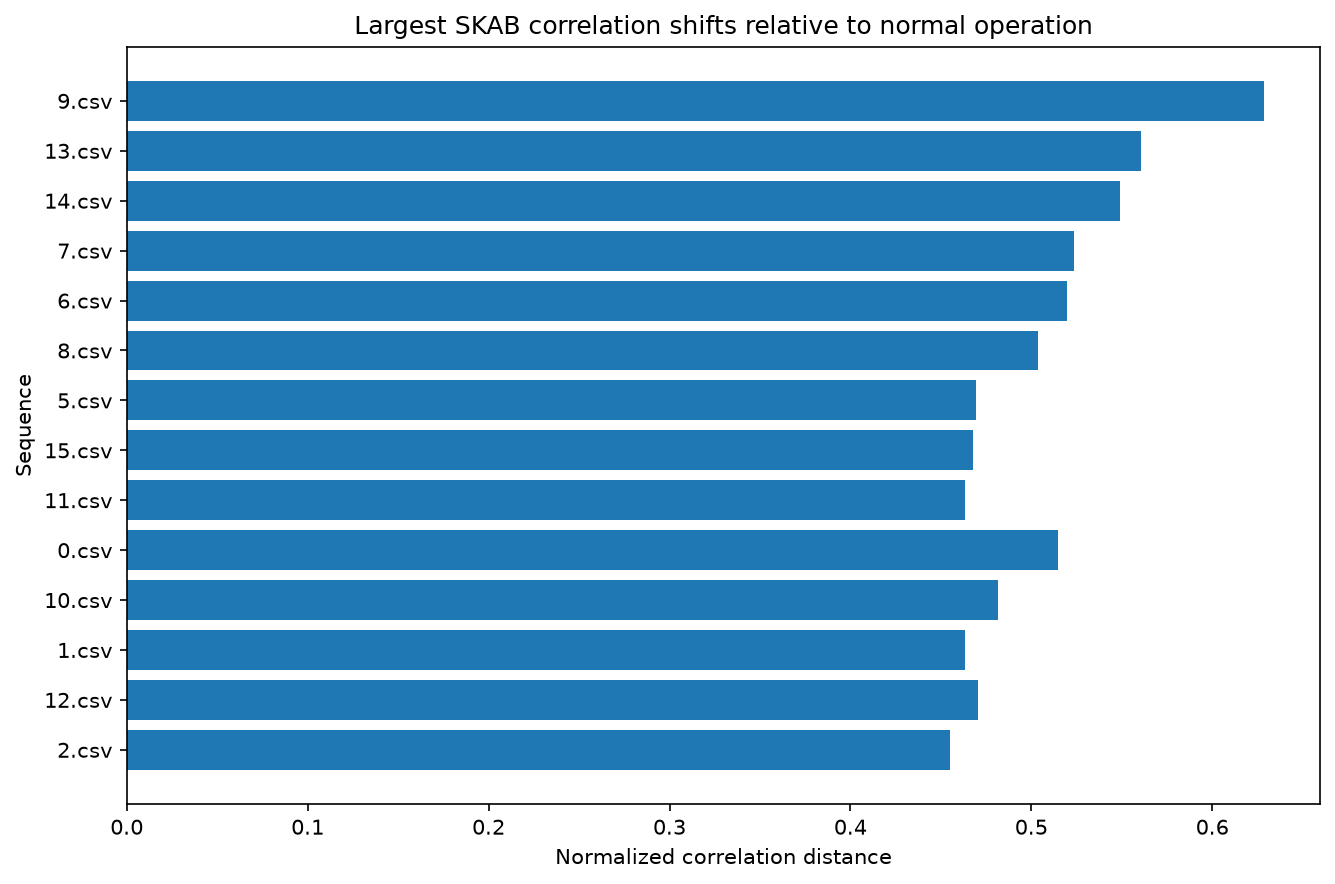

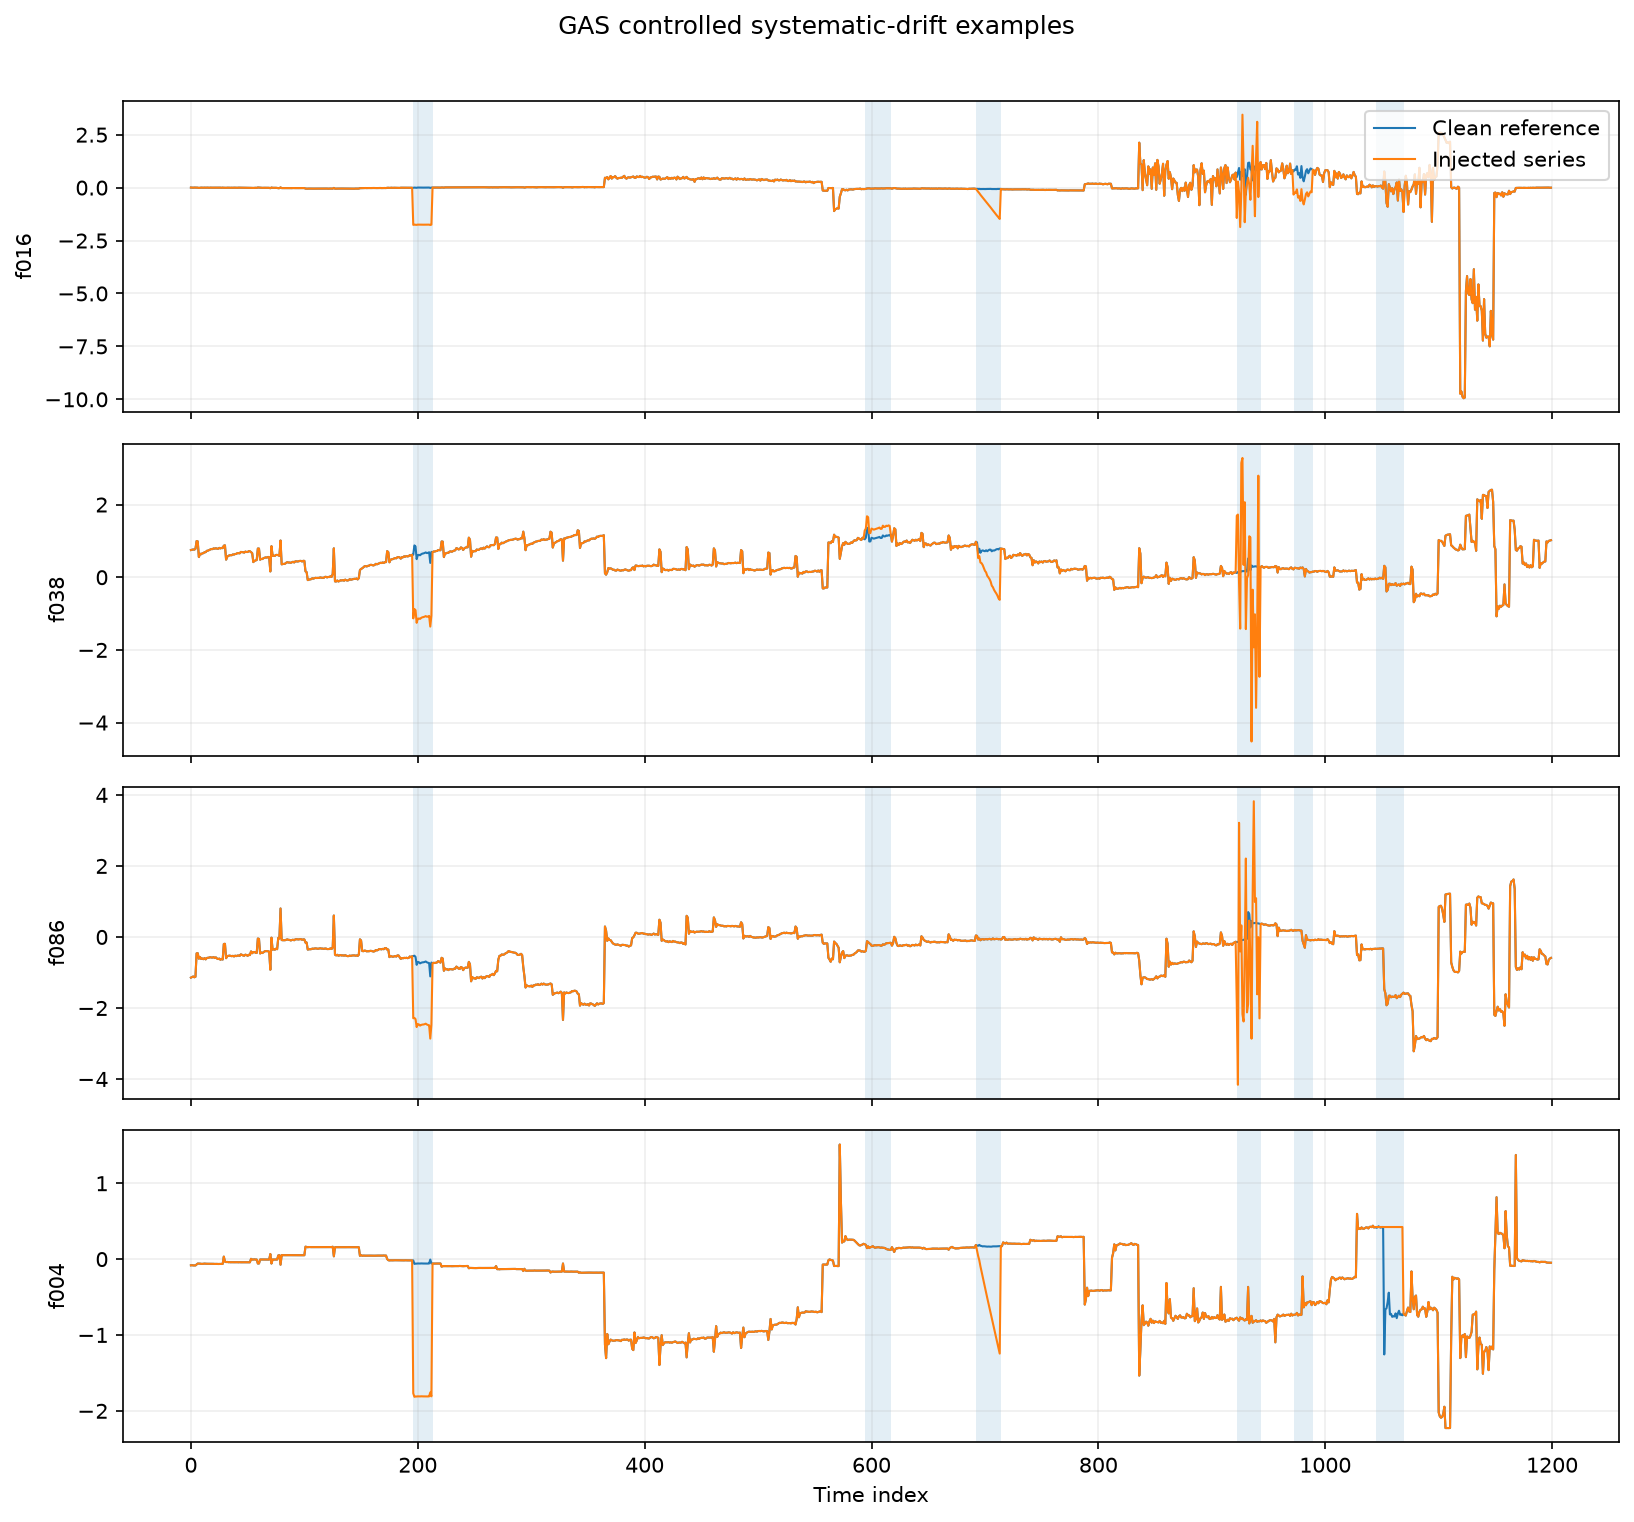

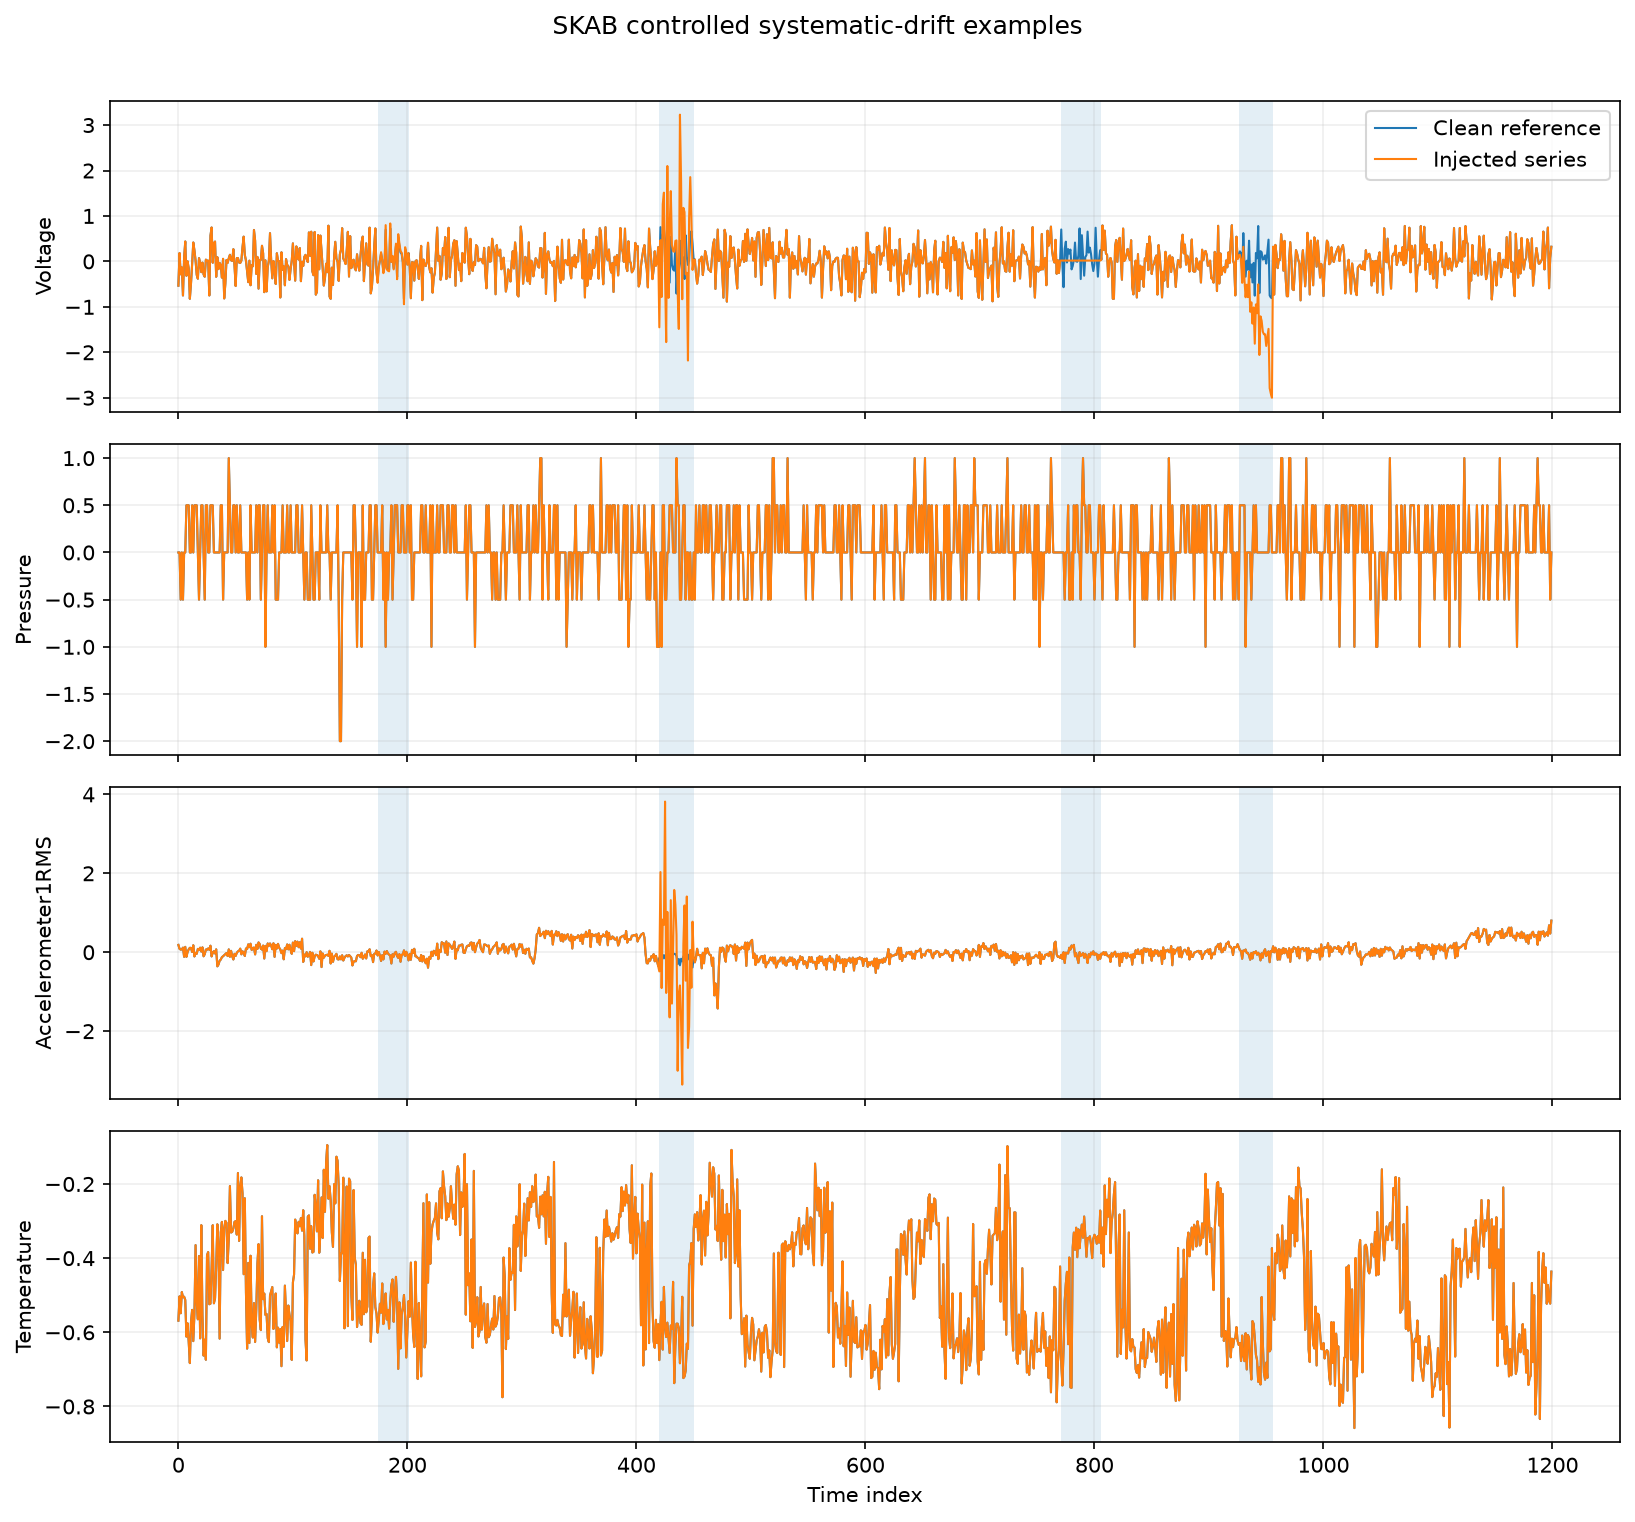

In [11]:
figure_dir = config["paths"]["results"] / "data" / "figures"
for figure_name in [
    "gas_samples_by_batch.png",
    "gas_composition_heatmap.png",
    "gas_natural_drift_index.png",
    "gas_sensor_drift_heatmap.png",
    "gas_residual_pca.png",
    "skab_anomaly_coverage.png",
    "skab_representative_sequence.png",
    "skab_correlation_shift_ranking.png",
    "skab_pca_normal_vs_anomaly.png",
    "gas_controlled_drift_examples.png",
    "skab_controlled_drift_examples.png",
]:
    path = figure_dir / figure_name
    if path.exists():
        display(Image(filename=str(path)))


## Completion audit

Notebook 02 and Notebook 03 must use the revised `manuscript_v2` result directory. Old preliminary CSV files are intentionally excluded from the new aggregation.


In [12]:
required = [
    config["paths"]["benchmarks"] / "gas_controlled.npz",
    config["paths"]["benchmarks"] / "skab_controlled.npz",
    config["paths"]["benchmarks"] / "gas_sensor_scenario_manifest.csv",
    config["paths"]["benchmarks"] / "skab_scenario_manifest.csv",
    config["paths"]["benchmarks"] / "gas_natural_later_batches.npz",
    config["paths"]["results"] / "data" / "skab_native_manifest.csv",
]
missing = [str(path) for path in required if not path.exists()]
if missing:
    raise FileNotFoundError("Missing required outputs:\n" + "\n".join(missing))
print("Notebook 01 completed successfully.")


Notebook 01 completed successfully.
